# LSTM Model


## Binary Cross Entropy

### Basic LSTM

Septic patients: 761
Nonseptic patients: 7496
Total patients: 8257
X shape: (8257, 42, 16)
y shape: (8257,)
Time steps used: 42
Variables: 16
Positive rate: 0.09216422429453797

SPLIT 1 OF 5
Train patients: 6605
Validation patients: 1652
Train positive rate: 0.09220287660862983
Validation positive rate: 0.09200968523002422
Class weights:
{np.int32(0): np.float64(0.550783855903936), np.int32(1): np.float64(5.422824302134647)}

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,961 (97.50 KB)

 Trainable params: 24,961 (97.50 KB)

...

Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - acc: 0.5567 - auprc: 0.1195 - auroc: 0.5569 - loss: 0.6874 - val_acc: 0.5575 - val_auprc: 0.1571 - val_auroc: 0.6460 - val_loss: 0.6949
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.6460 - auprc: 0.1436 - auroc: 0.6097 - loss: 0.6723 - val_acc: 0.8178 - val_auprc: 0.2613 - val_auroc: 0.6917 - val_loss: 0.6213
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.7814 - auprc: 0.1905 - auroc: 0.6458 - loss: 0.6488 - val_acc: 0.8396 - val_auprc: 0.2646 - val_auroc: 0.7031 - val_loss: 0.6591
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.7822 - auprc: 0.1979 - auroc: 0.6596 - loss: 0.6416 - val_acc: 0.8517 - val_auprc: 0.2607 - val_auroc: 0.7058 - val_loss: 0.6107
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.7853 - auprc: 0.2131 - auroc: 0.6899 - loss: 0.6270 - val_acc: 0.7367 - val_auprc: 0.2468 - val_auroc: 0.7323 - val_loss: 0.6296
Epoch 6/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - ac

,split,train_patients,val_patients,train_positive_rate,val_positive_rate,best_epoch_auprc,best_val_auprc,best_epoch_loss,best_val_loss,final_val_loss,final_val_accuracy,final_val_f1,final_val_auroc,final_val_auprc
0,1,6605,1652,0.092203,0.09201,10,0.287140,4,0.610689,0.652192,0.910412,0.108434,0.663397,0.219602
1,2,6605,1652,0.092203,0.09201,19,0.315376,17,0.544227,0.594059,0.810533,0.362525,0.766513,0.314955
2,3,6605,1652,0.092203,0.09201,5,0.258646,8,0.570158,0.595590,0.872881,0.295302,0.685561,0.239149
3,4,6605,1652,0.092203,0.09201,18,0.295285,14,0.591816,0.619728,0.829903,0.295739,0.705581,0.288599
4,5,6605,1652,0.092203,0.09201,13,0.253068,19,0.546229,0.720106,0.509685,0.213592,0.656605,0.194008



AVERAGE RESULTS ACROSS SPLITS


,best_val_auprc,best_val_loss,final_val_loss,final_val_accuracy,final_val_f1,final_val_auroc,final_val_auprc
mean,0.281903,0.572624,0.636335,0.786683,0.255119,0.695532,0.251263
std,0.025977,0.028838,0.052422,0.159612,0.097522,0.044121,0.049694



Best split based on validation AUPRC: 2
Best validation AUPRC: 0.31537631154060364


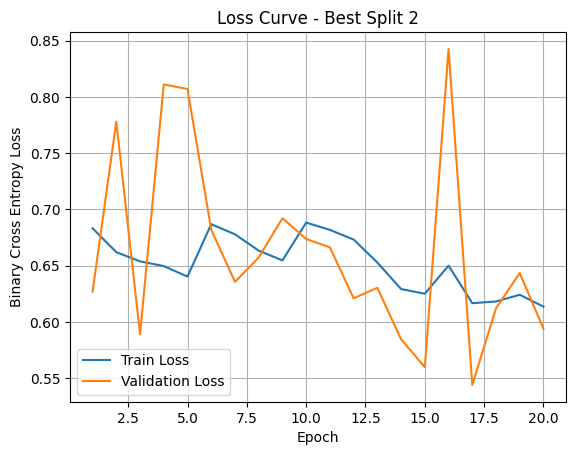

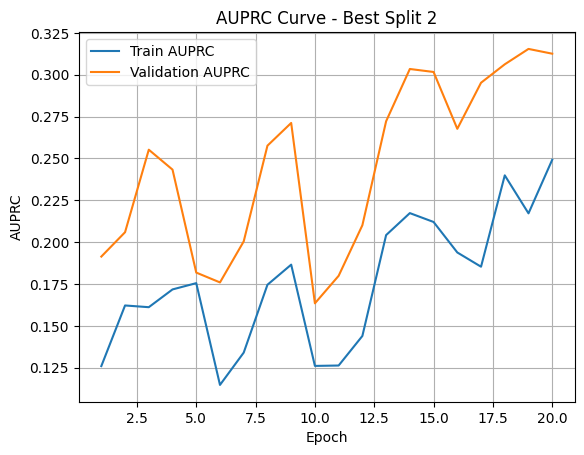

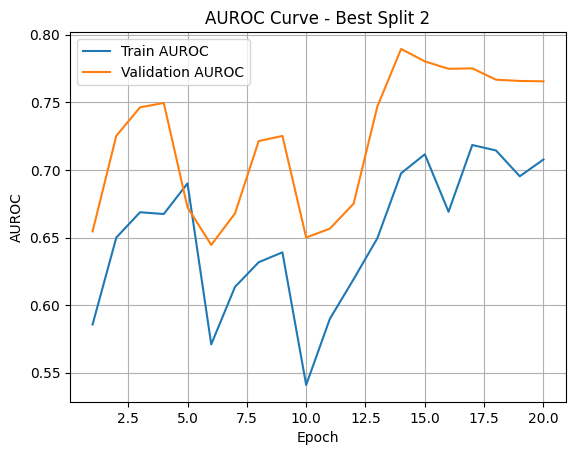


Confusion Matrix for Best Split:
[[1250  250]
 [  63   89]]


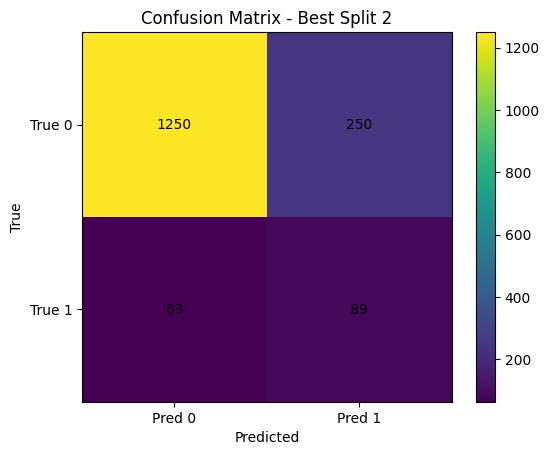

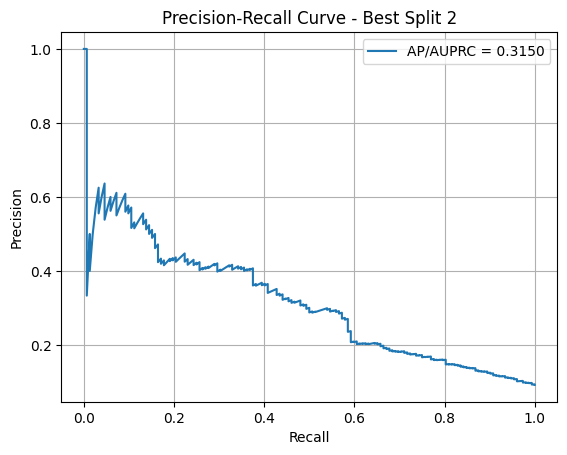

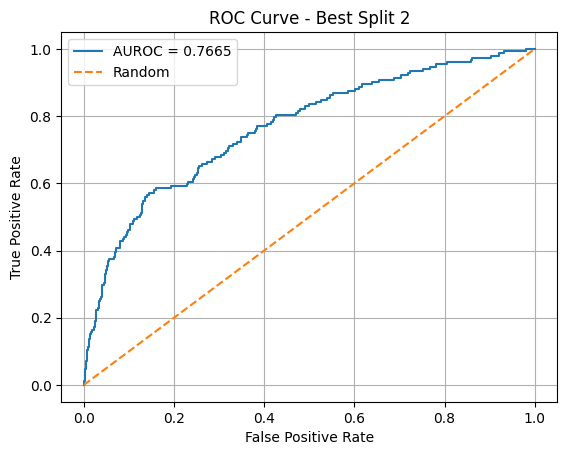

In [5]:
import os
import random as rn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras import backend as K

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight


# ============================================================
# 1. FIXED SETTINGS
# ============================================================

filesPath = "/Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Dataset_A"

numTSInitial = 48
numHRBef = 6

# Fixed model settings
numNodes = 64
percDropout = 0.5
batch_size = 128

# Fixed training settings
numEpochs = 20
learning_rate = 1e-3
test_size = 0.20
seed = 1

# Number of different train/validation splits
num_splits = 5

USE_CLASS_WEIGHTS = True
threshold = 0.5


# ============================================================
# 2. SET SEEDS
# ============================================================

def set_seeds(seed=1):
    np.random.seed(seed)
    rn.seed(seed)
    tf.random.set_seed(seed)


set_seeds(seed)


# ============================================================
# 3. LOAD DATA
# ============================================================

def getSequences(df_pos, df_neg, numTS):
    x_pos = df_pos.values
    x_neg = df_neg.values

    sequences_pos = []
    for i in range(0, len(x_pos), numTS):
        patient = x_pos[i:i + numTS, :]
        if patient.shape[0] == numTS:
            sequences_pos.append(patient)

    sequences_neg = []
    for i in range(0, len(x_neg), numTS):
        patient = x_neg[i:i + numTS, :]
        if patient.shape[0] == numTS:
            sequences_neg.append(patient)

    return sequences_pos, sequences_neg


def build_Xy(filesPath, numTSInitial=48, numHRBef=6):
    septic_path = os.path.join(filesPath, "septic.csv")
    nonseptic_path = os.path.join(filesPath, "nonseptic.csv")

    df_pos = pd.read_csv(septic_path)
    df_neg = pd.read_csv(nonseptic_path)

    df_pos = df_pos.drop(columns=["SepsisLabel"], errors="ignore")
    df_neg = df_neg.drop(columns=["SepsisLabel"], errors="ignore")

    common_cols = df_pos.columns.intersection(df_neg.columns)

    df_pos = df_pos[common_cols]
    df_neg = df_neg[common_cols]

    sequences_pos, sequences_neg = getSequences(df_pos, df_neg, numTSInitial)

    X = np.array(sequences_pos + sequences_neg)

    y = np.concatenate([
        np.ones(len(sequences_pos)),
        np.zeros(len(sequences_neg))
    ])

    inds = np.random.choice(len(X), len(X), replace=False)
    X = X[inds]
    y = y[inds]

    numTS = numTSInitial - numHRBef
    X = X[:, 0:numTS, :]

    numVariables = X.shape[2]

    print("Septic patients:", len(sequences_pos))
    print("Nonseptic patients:", len(sequences_neg))
    print("Total patients:", X.shape[0])
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("Time steps used:", numTS)
    print("Variables:", numVariables)
    print("Positive rate:", y.mean())

    if np.isnan(X).sum() > 0:
        print("WARNING: X contains NaN values. Replacing NaN with 0.")
        X = np.nan_to_num(X, nan=0.0)

    return X.astype("float32"), y.astype("int32"), numTS, numVariables, common_cols


X, y, numTS, numVariables, columns = build_Xy(
    filesPath=filesPath,
    numTSInitial=numTSInitial,
    numHRBef=numHRBef
)


# ============================================================
# 4. CREATE SIMPLE LSTM MODEL
# ============================================================

def create_simple_lstm(numTS, numVariables, numNodes, percDropout, learning_rate):
    model = Sequential()

    model.add(Input(shape=(numTS, numVariables)))

    model.add(LSTM(numNodes))

    model.add(Dropout(percDropout))

    model.add(Dense(numNodes, activation="relu"))

    model.add(Dropout(percDropout))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="acc"),
            tf.keras.metrics.AUC(name="auroc"),
            tf.keras.metrics.AUC(curve="PR", name="auprc")
        ]
    )

    return model


# ============================================================
# 5. CREATE SPLITTER
# ============================================================

splitter = StratifiedShuffleSplit(
    n_splits=num_splits,
    test_size=test_size,
    random_state=seed
)


# ============================================================
# 6. TRAIN ACROSS MULTIPLE SPLITS
# ============================================================

all_results = []
all_histories = []

best_model = None
best_history = None
best_split_number = None
best_split_val_auprc = -np.inf
best_split_data = None

for split_number, (train_idx, val_idx) in enumerate(splitter.split(X, y), start=1):

    print("\n" + "=" * 70)
    print(f"SPLIT {split_number} OF {num_splits}")
    print("=" * 70)

    X_train = X[train_idx]
    X_val = X[val_idx]

    y_train = y[train_idx]
    y_val = y[val_idx]

    print("Train patients:", X_train.shape[0])
    print("Validation patients:", X_val.shape[0])
    print("Train positive rate:", y_train.mean())
    print("Validation positive rate:", y_val.mean())

    # ========================================================
    # CLASS WEIGHTS FOR THIS SPLIT
    # ========================================================

    if USE_CLASS_WEIGHTS:
        classes = np.unique(y_train)

        class_weights_arr = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=y_train
        )

        class_weight_dict = dict(zip(classes, class_weights_arr))

        print("Class weights:")
        print(class_weight_dict)
    else:
        class_weight_dict = None

    # ========================================================
    # CREATE AND TRAIN MODEL FOR THIS SPLIT
    # ========================================================

    K.clear_session()
    set_seeds(seed + split_number)

    model = create_simple_lstm(
        numTS=numTS,
        numVariables=numVariables,
        numNodes=numNodes,
        percDropout=percDropout,
        learning_rate=learning_rate
    )

    if split_number == 1:
        print("\nModel Summary:")
        model.summary()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=numEpochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        verbose=1
    )

    all_histories.append(history.history)

    # ========================================================
    # EVALUATE THIS SPLIT
    # ========================================================

    scores = model.evaluate(X_val, y_val, verbose=0)

    val_loss = scores[0]
    val_acc_keras = scores[1]
    val_auroc_keras = scores[2]
    val_auprc_keras = scores[3]

    y_val_proba = model.predict(
        X_val,
        batch_size=batch_size,
        verbose=0
    ).ravel()

    y_val_pred = (y_val_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    ap = average_precision_score(y_val, y_val_proba)

    try:
        auroc = roc_auc_score(y_val, y_val_proba)
    except ValueError:
        auroc = np.nan

    best_epoch_auprc = np.argmax(history.history["val_auprc"]) + 1
    best_val_auprc = np.max(history.history["val_auprc"])

    best_epoch_loss = np.argmin(history.history["val_loss"]) + 1
    best_val_loss = np.min(history.history["val_loss"])

    result = {
        "split": split_number,
        "train_patients": X_train.shape[0],
        "val_patients": X_val.shape[0],
        "train_positive_rate": y_train.mean(),
        "val_positive_rate": y_val.mean(),
        "best_epoch_auprc": best_epoch_auprc,
        "best_val_auprc": best_val_auprc,
        "best_epoch_loss": best_epoch_loss,
        "best_val_loss": best_val_loss,
        "final_val_loss": val_loss,
        "final_val_accuracy": accuracy,
        "final_val_f1": f1,
        "final_val_auroc": auroc,
        "final_val_auprc": ap
    }

    all_results.append(result)

    print("\nSplit Results:")
    print("Best epoch by validation AUPRC:", best_epoch_auprc)
    print("Best validation AUPRC:", best_val_auprc)
    print("Best epoch by validation loss:", best_epoch_loss)
    print("Best validation loss:", best_val_loss)
    print("Final validation loss:", val_loss)
    print("Validation accuracy:", accuracy)
    print("Validation F1 Score:", f1)
    print("Validation AUROC:", auroc)
    print("Validation AP / AUPRC:", ap)

    # Save best split based on validation AUPRC
    if best_val_auprc > best_split_val_auprc:
        best_split_val_auprc = best_val_auprc
        best_split_number = split_number
        best_model = model
        best_history = history.history
        best_split_data = {
            "X_val": X_val,
            "y_val": y_val,
            "y_val_proba": y_val_proba,
            "y_val_pred": y_val_pred,
            "confusion_matrix": confusion_matrix(y_val, y_val_pred),
            "auroc": auroc,
            "ap": ap
        }


# ============================================================
# 7. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(all_results)

print("\n" + "=" * 70)
print("ALL SPLIT RESULTS")
print("=" * 70)
display(results_df)

print("\n" + "=" * 70)
print("AVERAGE RESULTS ACROSS SPLITS")
print("=" * 70)

summary_df = results_df[
    [
        "best_val_auprc",
        "best_val_loss",
        "final_val_loss",
        "final_val_accuracy",
        "final_val_f1",
        "final_val_auroc",
        "final_val_auprc"
    ]
].agg(["mean", "std"])

display(summary_df)

print("\nBest split based on validation AUPRC:", best_split_number)
print("Best validation AUPRC:", best_split_val_auprc)


# ============================================================
# 8. PLOT BEST SPLIT LOSS CURVE
# ============================================================

epochs = range(1, len(best_history["loss"]) + 1)

plt.figure()
plt.plot(epochs, best_history["loss"], label="Train Loss")
plt.plot(epochs, best_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title(f"Loss Curve - Best Split {best_split_number}")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 9. PLOT BEST SPLIT AUPRC CURVE
# ============================================================

plt.figure()
plt.plot(epochs, best_history["auprc"], label="Train AUPRC")
plt.plot(epochs, best_history["val_auprc"], label="Validation AUPRC")
plt.xlabel("Epoch")
plt.ylabel("AUPRC")
plt.title(f"AUPRC Curve - Best Split {best_split_number}")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 10. PLOT BEST SPLIT AUROC CURVE
# ============================================================

plt.figure()
plt.plot(epochs, best_history["auroc"], label="Train AUROC")
plt.plot(epochs, best_history["val_auroc"], label="Validation AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title(f"AUROC Curve - Best Split {best_split_number}")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 11. CONFUSION MATRIX FOR BEST SPLIT
# ============================================================

cm = best_split_data["confusion_matrix"]

print("\nConfusion Matrix for Best Split:")
print(cm)

plt.figure()
plt.imshow(cm)
plt.title(f"Confusion Matrix - Best Split {best_split_number}")
plt.colorbar()

plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


# ============================================================
# 12. PRECISION-RECALL CURVE FOR BEST SPLIT
# ============================================================

precision, recall, pr_thresholds = precision_recall_curve(
    best_split_data["y_val"],
    best_split_data["y_val_proba"]
)

plt.figure()
plt.plot(
    recall,
    precision,
    label=f"AP/AUPRC = {best_split_data['ap']:.4f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve - Best Split {best_split_number}")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 13. ROC CURVE FOR BEST SPLIT
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    best_split_data["y_val"],
    best_split_data["y_val_proba"]
)

plt.figure()
plt.plot(
    fpr,
    tpr,
    label=f"AUROC = {best_split_data['auroc']:.4f}"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - Best Split {best_split_number}")
plt.legend()
plt.grid(True)
plt.show()

### Optimze Hyperparameter

In [ ]:
import os
import random as rn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras import backend as K

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight


# ============================================================
# 1. FIXED SETTINGS
# ============================================================

filesPath = "/Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Dataset_A"

numTSInitial = 48
numHRBef = 6

# Training settings
numEpochs = 300
test_size = 0.20
seed = 1

# Number of train/validation splits per parameter combination
num_splits = 5

# Number of random parameter combinations to test
num_random_trials = 10

USE_CLASS_WEIGHTS = True
threshold = 0.5


# ============================================================
# 2. RANDOM SEARCH SPACE
# ============================================================

search_space = {
    "numNodes": [32, 64, 128],
    "percDropout": [0.2, 0.3, 0.4, 0.5],
    "batch_size": [32, 64, 128],
    "learning_rate": [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]
}


# ============================================================
# 3. SET SEEDS
# ============================================================

def set_seeds(seed=1):
    np.random.seed(seed)
    rn.seed(seed)
    tf.random.set_seed(seed)


set_seeds(seed)


# ============================================================
# 4. LOAD DATA
# ============================================================

def getSequences(df_pos, df_neg, numTS):
    x_pos = df_pos.values
    x_neg = df_neg.values

    sequences_pos = []
    for i in range(0, len(x_pos), numTS):
        patient = x_pos[i:i + numTS, :]
        if patient.shape[0] == numTS:
            sequences_pos.append(patient)

    sequences_neg = []
    for i in range(0, len(x_neg), numTS):
        patient = x_neg[i:i + numTS, :]
        if patient.shape[0] == numTS:
            sequences_neg.append(patient)

    return sequences_pos, sequences_neg


def build_Xy(filesPath, numTSInitial=48, numHRBef=6):
    septic_path = os.path.join(filesPath, "septic.csv")
    nonseptic_path = os.path.join(filesPath, "nonseptic.csv")

    df_pos = pd.read_csv(septic_path)
    df_neg = pd.read_csv(nonseptic_path)

    # Remove label column from features
    df_pos = df_pos.drop(columns=["SepsisLabel"], errors="ignore")
    df_neg = df_neg.drop(columns=["SepsisLabel"], errors="ignore")

    # Keep only shared columns
    common_cols = df_pos.columns.intersection(df_neg.columns)

    df_pos = df_pos[common_cols]
    df_neg = df_neg[common_cols]

    sequences_pos, sequences_neg = getSequences(df_pos, df_neg, numTSInitial)

    X = np.array(sequences_pos + sequences_neg)

    y = np.concatenate([
        np.ones(len(sequences_pos)),
        np.zeros(len(sequences_neg))
    ])

    # Shuffle patients
    inds = np.random.choice(len(X), len(X), replace=False)
    X = X[inds]
    y = y[inds]

    # Use only first 48 - numHRBef time steps
    numTS = numTSInitial - numHRBef
    X = X[:, 0:numTS, :]

    numVariables = X.shape[2]

    print("Septic patients:", len(sequences_pos))
    print("Nonseptic patients:", len(sequences_neg))
    print("Total patients:", X.shape[0])
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("Time steps used:", numTS)
    print("Variables:", numVariables)
    print("Positive rate:", y.mean())

    # LSTM cannot train with NaN values
    if np.isnan(X).sum() > 0:
        print("WARNING: X contains NaN values. Replacing NaN with 0.")
        X = np.nan_to_num(X, nan=0.0)

    return X.astype("float32"), y.astype("int32"), numTS, numVariables, common_cols


X, y, numTS, numVariables, columns = build_Xy(
    filesPath=filesPath,
    numTSInitial=numTSInitial,
    numHRBef=numHRBef
)


# ============================================================
# 5. CREATE LSTM MODEL
# ============================================================

def create_simple_lstm(numTS, numVariables, numNodes, percDropout, learning_rate):
    model = Sequential()

    model.add(Input(shape=(numTS, numVariables)))

    model.add(LSTM(numNodes))

    model.add(Dropout(percDropout))

    model.add(Dense(numNodes, activation="relu"))

    model.add(Dropout(percDropout))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="acc"),
            tf.keras.metrics.AUC(name="auroc"),
            tf.keras.metrics.AUC(curve="PR", name="auprc")
        ]
    )

    return model


# ============================================================
# 6. SAMPLE RANDOM PARAMETERS
# ============================================================

def sample_random_params(search_space, rng):
    params = {
        "numNodes": int(rng.choice(search_space["numNodes"])),
        "percDropout": float(rng.choice(search_space["percDropout"])),
        "batch_size": int(rng.choice(search_space["batch_size"])),
        "learning_rate": float(rng.choice(search_space["learning_rate"]))
    }

    return params


# ============================================================
# 7. RANDOM SEARCH
# ============================================================

rng = np.random.default_rng(seed)

all_trial_results = []
all_split_results = []

best_model = None
best_history = None
best_trial_number = None
best_split_number = None
best_params = None
best_val_auprc_overall = -np.inf
best_split_data = None

for trial_number in range(1, num_random_trials + 1):

    params = sample_random_params(search_space, rng)

    numNodes = params["numNodes"]
    percDropout = params["percDropout"]
    batch_size = params["batch_size"]
    learning_rate = params["learning_rate"]

    print("\n" + "#" * 80)
    print(f"RANDOM SEARCH TRIAL {trial_number} OF {num_random_trials}")
    print("#" * 80)

    print("Trying parameters:")
    print("numNodes:", numNodes)
    print("percDropout:", percDropout)
    print("batch_size:", batch_size)
    print("learning_rate:", learning_rate)

    splitter = StratifiedShuffleSplit(
        n_splits=num_splits,
        test_size=test_size,
        random_state=seed + trial_number
    )

    split_results_for_trial = []

    for split_number, (train_idx, val_idx) in enumerate(splitter.split(X, y), start=1):

        print("\n" + "=" * 70)
        print(f"TRIAL {trial_number}, SPLIT {split_number} OF {num_splits}")
        print("=" * 70)

        X_train = X[train_idx]
        X_val = X[val_idx]

        y_train = y[train_idx]
        y_val = y[val_idx]

        print("Train patients:", X_train.shape[0])
        print("Validation patients:", X_val.shape[0])
        print("Train positive rate:", y_train.mean())
        print("Validation positive rate:", y_val.mean())

        # ====================================================
        # CLASS WEIGHTS
        # ====================================================

        if USE_CLASS_WEIGHTS:
            classes = np.unique(y_train)

            class_weights_arr = compute_class_weight(
                class_weight="balanced",
                classes=classes,
                y=y_train
            )

            class_weight_dict = {
                int(c): float(w)
                for c, w in zip(classes, class_weights_arr)
            }

            print("Class weights:")
            print(class_weight_dict)
        else:
            class_weight_dict = None

        # ====================================================
        # CREATE MODEL
        # ====================================================

        K.clear_session()
        set_seeds(seed + trial_number + split_number)

        model = create_simple_lstm(
            numTS=numTS,
            numVariables=numVariables,
            numNodes=numNodes,
            percDropout=percDropout,
            learning_rate=learning_rate
        )

        if trial_number == 1 and split_number == 1:
            print("\nModel Summary:")
            model.summary()

        # ====================================================
        # TRAIN MODEL
        # ====================================================

        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=numEpochs,
            batch_size=batch_size,
            class_weight=class_weight_dict,
            verbose=1
        )

        # ====================================================
        # EVALUATE MODEL
        # ====================================================

        scores = model.evaluate(X_val, y_val, verbose=0)

        val_loss = scores[0]
        val_acc_keras = scores[1]
        val_auroc_keras = scores[2]
        val_auprc_keras = scores[3]

        y_val_proba = model.predict(
            X_val,
            batch_size=batch_size,
            verbose=0
        ).ravel()

        y_val_pred = (y_val_proba >= threshold).astype(int)

        accuracy = accuracy_score(y_val, y_val_pred)
        f1 = f1_score(y_val, y_val_pred, zero_division=0)
        ap = average_precision_score(y_val, y_val_proba)

        try:
            auroc = roc_auc_score(y_val, y_val_proba)
        except ValueError:
            auroc = np.nan

        best_epoch_auprc = np.argmax(history.history["val_auprc"]) + 1
        best_val_auprc = np.max(history.history["val_auprc"])

        best_epoch_loss = np.argmin(history.history["val_loss"]) + 1
        best_val_loss = np.min(history.history["val_loss"])

        split_result = {
            "trial": trial_number,
            "split": split_number,

            "numNodes": numNodes,
            "percDropout": percDropout,
            "batch_size": batch_size,
            "learning_rate": learning_rate,

            "train_patients": X_train.shape[0],
            "val_patients": X_val.shape[0],
            "train_positive_rate": y_train.mean(),
            "val_positive_rate": y_val.mean(),

            "best_epoch_auprc": best_epoch_auprc,
            "best_val_auprc": best_val_auprc,

            "best_epoch_loss": best_epoch_loss,
            "best_val_loss": best_val_loss,

            "final_val_loss": val_loss,
            "final_val_accuracy": accuracy,
            "final_val_f1": f1,
            "final_val_auroc": auroc,
            "final_val_auprc": ap
        }

        split_results_for_trial.append(split_result)
        all_split_results.append(split_result)

        print("\nSplit Results:")
        print("Best epoch by validation AUPRC:", best_epoch_auprc)
        print("Best validation AUPRC:", best_val_auprc)
        print("Best epoch by validation loss:", best_epoch_loss)
        print("Best validation loss:", best_val_loss)
        print("Final validation loss:", val_loss)
        print("Validation accuracy:", accuracy)
        print("Validation F1 Score:", f1)
        print("Validation AUROC:", auroc)
        print("Validation AP / AUPRC:", ap)

        # Save best individual model based on validation AUPRC
        if best_val_auprc > best_val_auprc_overall:
            best_val_auprc_overall = best_val_auprc
            best_trial_number = trial_number
            best_split_number = split_number
            best_params = params.copy()
            best_model = model
            best_history = history.history

            best_split_data = {
                "X_val": X_val,
                "y_val": y_val,
                "y_val_proba": y_val_proba,
                "y_val_pred": y_val_pred,
                "confusion_matrix": confusion_matrix(y_val, y_val_pred),
                "auroc": auroc,
                "ap": ap
            }

    # ========================================================
    # AVERAGE RESULTS FOR THIS PARAMETER COMBINATION
    # ========================================================

    trial_df = pd.DataFrame(split_results_for_trial)

    trial_summary = {
        "trial": trial_number,

        "numNodes": numNodes,
        "percDropout": percDropout,
        "batch_size": batch_size,
        "learning_rate": learning_rate,

        "mean_best_val_auprc": trial_df["best_val_auprc"].mean(),
        "std_best_val_auprc": trial_df["best_val_auprc"].std(),

        "mean_best_val_loss": trial_df["best_val_loss"].mean(),
        "std_best_val_loss": trial_df["best_val_loss"].std(),

        "mean_final_val_loss": trial_df["final_val_loss"].mean(),
        "std_final_val_loss": trial_df["final_val_loss"].std(),

        "mean_final_val_accuracy": trial_df["final_val_accuracy"].mean(),
        "std_final_val_accuracy": trial_df["final_val_accuracy"].std(),

        "mean_final_val_f1": trial_df["final_val_f1"].mean(),
        "std_final_val_f1": trial_df["final_val_f1"].std(),

        "mean_final_val_auroc": trial_df["final_val_auroc"].mean(),
        "std_final_val_auroc": trial_df["final_val_auroc"].std(),

        "mean_final_val_auprc": trial_df["final_val_auprc"].mean(),
        "std_final_val_auprc": trial_df["final_val_auprc"].std()
    }

    all_trial_results.append(trial_summary)

    print("\n" + "-" * 70)
    print(f"TRIAL {trial_number} AVERAGE RESULTS")
    print("-" * 70)
    print("Mean best validation AUPRC:", trial_summary["mean_best_val_auprc"])
    print("Mean best validation loss:", trial_summary["mean_best_val_loss"])
    print("Mean final validation F1:", trial_summary["mean_final_val_f1"])
    print("Mean final validation AUROC:", trial_summary["mean_final_val_auroc"])
    print("Mean final validation AUPRC:", trial_summary["mean_final_val_auprc"])


# ============================================================
# 8. RANDOM SEARCH RESULTS TABLE
# ============================================================

trial_results_df = pd.DataFrame(all_trial_results)
split_results_df = pd.DataFrame(all_split_results)

# Sort by mean best validation AUPRC
trial_results_df = trial_results_df.sort_values(
    by="mean_best_val_auprc",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 80)
print("RANDOM SEARCH RESULTS SORTED BY MEAN BEST VALIDATION AUPRC")
print("=" * 80)
display(trial_results_df)

print("\n" + "=" * 80)
print("ALL SPLIT RESULTS")
print("=" * 80)
display(split_results_df)


# ============================================================
# 9. BEST PARAMETERS
# ============================================================

best_row = trial_results_df.iloc[0]

print("\n" + "=" * 80)
print("BEST PARAMETER COMBINATION BASED ON MEAN VALIDATION AUPRC")
print("=" * 80)

print("Best trial:", int(best_row["trial"]))
print("Best numNodes:", int(best_row["numNodes"]))
print("Best dropout:", best_row["percDropout"])
print("Best batch size:", int(best_row["batch_size"]))
print("Best learning rate:", best_row["learning_rate"])

print("\nAverage performance across splits:")
print("Mean best validation AUPRC:", best_row["mean_best_val_auprc"])
print("Std best validation AUPRC:", best_row["std_best_val_auprc"])
print("Mean best validation loss:", best_row["mean_best_val_loss"])
print("Mean final validation F1:", best_row["mean_final_val_f1"])
print("Mean final validation AUROC:", best_row["mean_final_val_auroc"])
print("Mean final validation AUPRC:", best_row["mean_final_val_auprc"])

print("\nBest individual model:")
print("Best trial number:", best_trial_number)
print("Best split number:", best_split_number)
print("Best individual validation AUPRC:", best_val_auprc_overall)
print("Best individual parameters:", best_params)


# ============================================================
# 10. PLOT BEST INDIVIDUAL MODEL LOSS CURVE
# ============================================================

epochs = range(1, len(best_history["loss"]) + 1)

plt.figure()
plt.plot(epochs, best_history["loss"], label="Train Loss")
plt.plot(epochs, best_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title(
    f"Loss Curve - Best Model "
    f"Trial {best_trial_number}, Split {best_split_number}"
)
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 11. PLOT BEST INDIVIDUAL MODEL AUPRC CURVE
# ============================================================

plt.figure()
plt.plot(epochs, best_history["auprc"], label="Train AUPRC")
plt.plot(epochs, best_history["val_auprc"], label="Validation AUPRC")
plt.xlabel("Epoch")
plt.ylabel("AUPRC")
plt.title(
    f"AUPRC Curve - Best Model "
    f"Trial {best_trial_number}, Split {best_split_number}"
)
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 12. PLOT BEST INDIVIDUAL MODEL AUROC CURVE
# ============================================================

plt.figure()
plt.plot(epochs, best_history["auroc"], label="Train AUROC")
plt.plot(epochs, best_history["val_auroc"], label="Validation AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title(
    f"AUROC Curve - Best Model "
    f"Trial {best_trial_number}, Split {best_split_number}"
)
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 13. CONFUSION MATRIX FOR BEST INDIVIDUAL MODEL
# ============================================================

cm = best_split_data["confusion_matrix"]

print("\nConfusion Matrix for Best Individual Model:")
print(cm)

plt.figure()
plt.imshow(cm)
plt.title(
    f"Confusion Matrix - Best Model "
    f"Trial {best_trial_number}, Split {best_split_number}"
)
plt.colorbar()

plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


# ============================================================
# 14. PRECISION-RECALL CURVE FOR BEST INDIVIDUAL MODEL
# ============================================================

precision, recall, pr_thresholds = precision_recall_curve(
    best_split_data["y_val"],
    best_split_data["y_val_proba"]
)

plt.figure()
plt.plot(
    recall,
    precision,
    label=f"AP/AUPRC = {best_split_data['ap']:.4f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    f"Precision-Recall Curve - Best Model "
    f"Trial {best_trial_number}, Split {best_split_number}"
)
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 15. ROC CURVE FOR BEST INDIVIDUAL MODEL
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    best_split_data["y_val"],
    best_split_data["y_val_proba"]
)

plt.figure()
plt.plot(
    fpr,
    tpr,
    label=f"AUROC = {best_split_data['auroc']:.4f}"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    f"ROC Curve - Best Model "
    f"Trial {best_trial_number}, Split {best_split_number}"
)
plt.legend()
plt.grid(True)
plt.show()

## Focal Binary Cross Entropy

In [ ]:
# ============================================================
# SIMPLE JUPYTER NOTEBOOK VERSION
# Fixed hyperparameters
# Loss = Focal Binary Cross Entropy
# No hyperparameter tuning loop
# ============================================================

import os
import random as rn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Input, LSTM, Dropout, Dense
from keras import backend as K

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)
from sklearn.utils.class_weight import compute_class_weight


# ============================================================
# 1. FIXED SETTINGS
# ============================================================

filesPath = "/Users/bryanbarrios/Desktop/MastersResearch/PredictiveModeling/Data/Dataset_A"

numTSInitial = 48
numHRBef = 6

# Keep these fixed
numNodes = 128
percDropout = 0.2
batch_size = 96

numEpochs = 400
learning_rate = 1e-3
test_size = 0.20
seed = 1

# ============================================================
# FOCAL LOSS SETTINGS
# ============================================================

# alpha gives more weight to the positive class, septic patients
# If septic patients are rare, alpha should usually be bigger than 0.5
FOCAL_ALPHA = 0.75

# gamma makes the model focus more on hard examples
# gamma = 0 is basically regular BCE
# gamma = 2 is a common choice
FOCAL_GAMMA = 2.0

# IMPORTANT:
# Do not use class weights and focal loss together at first.
# Focal loss already handles class imbalance using alpha.
USE_CLASS_WEIGHTS = False


# ============================================================
# 2. SET SEEDS
# ============================================================

def set_seeds(seed=1):
    np.random.seed(seed)
    rn.seed(seed)
    tf.random.set_seed(seed)

set_seeds(seed)


# ============================================================
# 3. LOAD DATA
# ============================================================

def getSequences(df_pos, df_neg, numTS):
    x_pos = df_pos.values
    x_neg = df_neg.values

    sequences_pos = []
    for i in range(0, len(x_pos), numTS):
        patient = x_pos[i:i + numTS, :]
        if patient.shape[0] == numTS:
            sequences_pos.append(patient)

    sequences_neg = []
    for i in range(0, len(x_neg), numTS):
        patient = x_neg[i:i + numTS, :]
        if patient.shape[0] == numTS:
            sequences_neg.append(patient)

    return sequences_pos, sequences_neg


def build_Xy(filesPath, numTSInitial=48, numHRBef=6):
    septic_path = os.path.join(filesPath, "septic.csv")
    nonseptic_path = os.path.join(filesPath, "nonseptic.csv")

    df_pos = pd.read_csv(septic_path)
    df_neg = pd.read_csv(nonseptic_path)

    # Remove label column from features
    df_pos = df_pos.drop(columns=["SepsisLabel"], errors="ignore")
    df_neg = df_neg.drop(columns=["SepsisLabel"], errors="ignore")

    # Keep only shared columns
    common_cols = df_pos.columns.intersection(df_neg.columns)
    df_pos = df_pos[common_cols]
    df_neg = df_neg[common_cols]

    sequences_pos, sequences_neg = getSequences(df_pos, df_neg, numTSInitial)

    X = np.array(sequences_pos + sequences_neg)

    y = np.concatenate([
        np.ones(len(sequences_pos)),
        np.zeros(len(sequences_neg))
    ])

    # Shuffle patients
    inds = np.random.choice(len(X), len(X), replace=False)
    X = X[inds]
    y = y[inds]

    # Use only first 48 - numHRBef time steps
    numTS = numTSInitial - numHRBef
    X = X[:, 0:numTS, :]

    numVariables = X.shape[2]

    print("Septic patients:", len(sequences_pos))
    print("Nonseptic patients:", len(sequences_neg))
    print("Total patients:", X.shape[0])
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("Time steps used:", numTS)
    print("Variables:", numVariables)
    print("Positive rate:", y.mean())

    # LSTM cannot train with NaN values
    if np.isnan(X).sum() > 0:
        print("WARNING: X contains NaN values. Replacing NaN with 0.")
        X = np.nan_to_num(X, nan=0.0)

    return X.astype("float32"), y.astype("float32"), numTS, numVariables, common_cols


X, y, numTS, numVariables, columns = build_Xy(
    filesPath=filesPath,
    numTSInitial=numTSInitial,
    numHRBef=numHRBef
)


# ============================================================
# 4. FOCAL BINARY CROSS ENTROPY LOSS
# ============================================================

def binary_focal_loss(alpha=0.75, gamma=2.0):
    """
    Focal Binary Cross Entropy Loss.

    alpha:
        Controls class imbalance.
        alpha > 0.5 gives more weight to class 1.
        In your case, class 1 = septic patient.

    gamma:
        Controls how much the loss focuses on hard examples.
        gamma = 0 makes it similar to regular binary cross entropy.
        gamma = 2 is commonly used.
    """

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # Make sure shapes match
        y_true = tf.reshape(y_true, tf.shape(y_pred))

        # Avoid log(0)
        epsilon = K.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        # Binary cross entropy part
        bce = -(
            y_true * tf.math.log(y_pred)
            + (1.0 - y_true) * tf.math.log(1.0 - y_pred)
        )

        # p_t = probability assigned to the true class
        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)

        # alpha weighting
        # septic class y=1 gets alpha
        # nonseptic class y=0 gets 1-alpha
        alpha_factor = y_true * alpha + (1.0 - y_true) * (1.0 - alpha)

        # focal weighting
        focal_weight = alpha_factor * tf.pow(1.0 - p_t, gamma)

        # final focal loss
        loss = focal_weight * bce

        return tf.reduce_mean(loss)

    return loss_fn


# ============================================================
# 5. CREATE SIMPLE LSTM MODEL
# ============================================================

def create_simple_lstm(
    numTS,
    numVariables,
    numNodes,
    percDropout,
    learning_rate,
    focal_alpha,
    focal_gamma
):
    model = Sequential()

    model.add(Input(shape=(numTS, numVariables)))

    model.add(LSTM(numNodes))

    model.add(Dropout(percDropout))

    model.add(Dense(numNodes, activation="relu"))

    model.add(Dropout(percDropout))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=binary_focal_loss(alpha=focal_alpha, gamma=focal_gamma),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="acc"),
            tf.keras.metrics.AUC(name="auroc"),
            tf.keras.metrics.AUC(curve="PR", name="auprc")
        ]
    )

    return model


# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# ============================================================

splitter = StratifiedShuffleSplit(
    n_splits=5,
    test_size=test_size,
    random_state=seed
)

train_idx, val_idx = next(splitter.split(X, y))

X_train = X[train_idx]
X_val = X[val_idx]

y_train = y[train_idx]
y_val = y[val_idx]

print("\nTrain patients:", X_train.shape[0])
print("Validation patients:", X_val.shape[0])
print("Train positive rate:", y_train.mean())
print("Validation positive rate:", y_val.mean())


# ============================================================
# 7. CLASS WEIGHTS
# ============================================================

if USE_CLASS_WEIGHTS:
    classes = np.unique(y_train)

    class_weights_arr = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    class_weight_dict = dict(zip(classes, class_weights_arr))

    print("\nClass weights:")
    print(class_weight_dict)
else:
    class_weight_dict = None

    print("\nClass weights are OFF.")
    print("Using focal loss alpha instead.")


# ============================================================
# 8. TRAIN MODEL
# ============================================================

K.clear_session()
set_seeds(seed)

model = create_simple_lstm(
    numTS=numTS,
    numVariables=numVariables,
    numNodes=numNodes,
    percDropout=percDropout,
    learning_rate=learning_rate,
    focal_alpha=FOCAL_ALPHA,
    focal_gamma=FOCAL_GAMMA
)

print("\nModel Summary:")
model.summary()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=numEpochs,
    batch_size=batch_size,
    class_weight=class_weight_dict,
    verbose=1
)


# ============================================================
# 9. EVALUATE MODEL
# ============================================================

scores = model.evaluate(X_val, y_val, verbose=0)

val_loss = scores[0]
val_acc = scores[1]
val_auroc_keras = scores[2]
val_auprc_keras = scores[3]

y_val_proba = model.predict(X_val, batch_size=batch_size, verbose=0).ravel()
y_val_pred = (y_val_proba >= 0.5).astype(int)

accuracy = accuracy_score(y_val, y_val_pred)
ap = average_precision_score(y_val, y_val_proba)

try:
    auroc = roc_auc_score(y_val, y_val_proba)
except ValueError:
    auroc = np.nan

best_epoch = np.argmax(history.history["val_auprc"]) + 1
best_val_auprc = np.max(history.history["val_auprc"])
best_val_loss = np.min(history.history["val_loss"])

print("\n================ RESULTS ================")
print("Fixed nodes:", numNodes)
print("Fixed dropout:", percDropout)
print("Fixed batch size:", batch_size)
print("Learning rate:", learning_rate)
print("Focal alpha:", FOCAL_ALPHA)
print("Focal gamma:", FOCAL_GAMMA)
print("Best epoch based on validation AUPRC:", best_epoch)
print("Best validation focal loss:", best_val_loss)
print("Best validation AUPRC:", best_val_auprc)
print("Final validation focal loss:", val_loss)
print("Validation accuracy:", accuracy)
print("Validation AUROC:", auroc)
print("Validation AP / AUPRC:", ap)


# ============================================================
# 10. LOSS CURVE
# ============================================================

epochs = range(1, len(history.history["loss"]) + 1)

plt.figure()
plt.plot(epochs, history.history["loss"], label="Train Focal Loss")
plt.plot(epochs, history.history["val_loss"], label="Validation Focal Loss")
plt.xlabel("Epoch")
plt.ylabel("Focal Binary Cross Entropy Loss")
plt.title("Focal Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 11. AUPRC CURVE
# ============================================================

plt.figure()
plt.plot(epochs, history.history["auprc"], label="Train AUPRC")
plt.plot(epochs, history.history["val_auprc"], label="Validation AUPRC")
plt.xlabel("Epoch")
plt.ylabel("AUPRC")
plt.title("AUPRC Curve")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 12. AUROC CURVE
# ============================================================

plt.figure()
plt.plot(epochs, history.history["auroc"], label="Train AUROC")
plt.plot(epochs, history.history["val_auroc"], label="Validation AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("AUROC Curve")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_val, y_val_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


# ============================================================
# 14. PRECISION-RECALL CURVE
# ============================================================

precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 15. ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()